In [2]:
import os

os.chdir("/home/moritzmzw/SERPENS")

print("Current Working Directory:", os.getcwd())

/tmp/XRwLls
Current Working Directory: /home/moritzmzw/SERPENS


In [3]:
from src.serpens_simulation import SerpensSimulation
from src.serpens_analyzer import SerpensAnalyzer
try:
    from src.cerpens import CerpensSimulation
except (OSError, ImportError, ModuleNotFoundError):
    pass
from src.species import Species
import matplotlib

### Setting up a Simulation for Visualization Examples

In this notebook, we'll demonstrate the various visualization functions available in the SerpensAnalyzer class:
- plot_planar
- plot_lineofsight
- plot_1d_cut
- plot_3d
- plot_phasecurve (after running calculate_phasecurve)

First, let's set up a simulation with a sourcing object to generate data for visualization.

In [5]:
from src.parameters import GLOBAL_PARAMETERS

GLOBAL_PARAMETERS.reset()
GLOBAL_PARAMETERS.set("lorentz_enabled", False)
GLOBAL_PARAMETERS.set("lorentz_central_index", "1")  # Note: Follows order in 'resources/objects.json'
GLOBAL_PARAMETERS.set("lorentz_moment_Am2", [0.0, 0.0, 1.5e24])  # dipole moment vector [A m^2]
GLOBAL_PARAMETERS.set("magnetic_rotation", [0.0, 0.0, 1.758e-4])
GLOBAL_PARAMETERS.set("magnetic_tilt_degrees", 60)
GLOBAL_PARAMETERS.set("lorentz_softening_m", 70000e3)  # optional, can set to planet radius to avoid r~0
GLOBAL_PARAMETERS.set("fix_source_circular_orbit", False)

In [ ]:
# Create a simulation with the Jupiter system
sim = CerpensSimulation(system="Jupiter")

# Declare Io as a source for Sodium
sim.object_to_source(
    "Io",
    species=[
        Species(
            'Na',
            n_th=0, n_sp=20,
            mass_per_sec=10**4.8,
            v_b=0.95*1000,
            v_M=15.24*10000,
            lifetime=4*6000,
            beta=0,
            charge_e=-1
        ),
        Species(
            'Na',
            n_th=0, n_sp=20,
            mass_per_sec=10**4.8,
            v_b=0.95*1000,
            v_M=15.24*10000,
            lifetime=4*6000,
            beta=0,
            charge_e=0
        )
    ]
)

# Run the simulation for x orbits with y spawns
sim.advance(orbits=3, spawns=30, orbits_reference="Io")

Initializing new simulation instance...
	 	 ... done!


  0%|          | 0/30 [00:00<?, ?it/s]

### Creating an Analyzer

Now that we have simulation data, let's create an analyzer to visualize it.

In [5]:
# Create an analyzer with Io as the reference system
sa = SerpensAnalyzer(reference_system="Io")

### 1. Planar View Visualization

The `plot_planar` function creates a top-down view of the orbital plane.

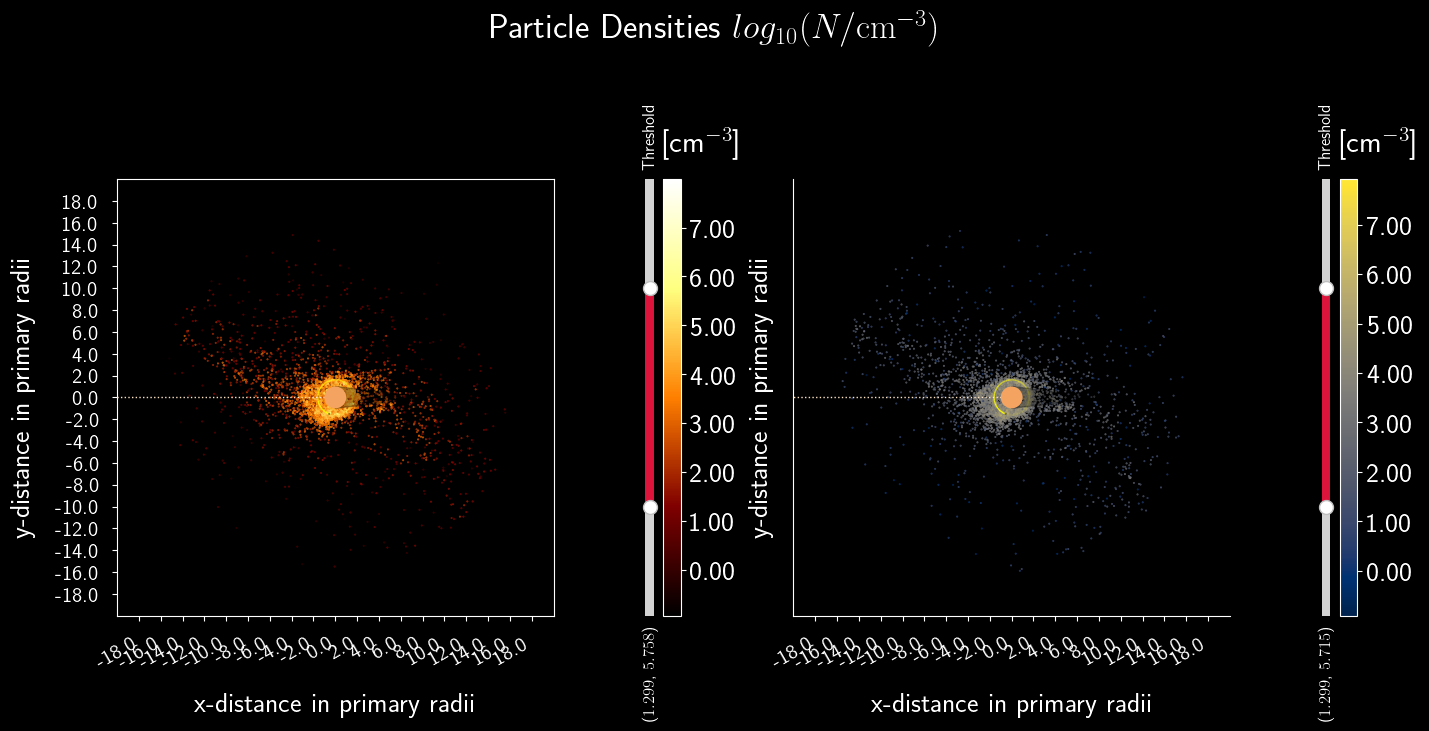

In [6]:
%matplotlib inline
import matplotlib as mpl

# Basic planar plot
sa.plot_planar(
    timestep=30,
    figsize=8,
    colormap=[mpl.colormaps["afmhot"], mpl.colormaps["cividis"]],
    single_plot=False
)

In [ ]:
# Planar plot with customizations
sa.plot_planar(
    timestep=8,
    scatter=True,       # (Don't) Show density scatter
    triplot=True,       # (Don't) show triangulation
    trialpha=.4,
    figsize=8,
    colormap=matplotlib.colormaps["magma"],
    #single_plot=True,
    interactive=False   # Removed threshold-bar
)

### 2. Line of Sight Visualization

The `plot_lineofsight` function creates a view from the line-of-sight perspective.

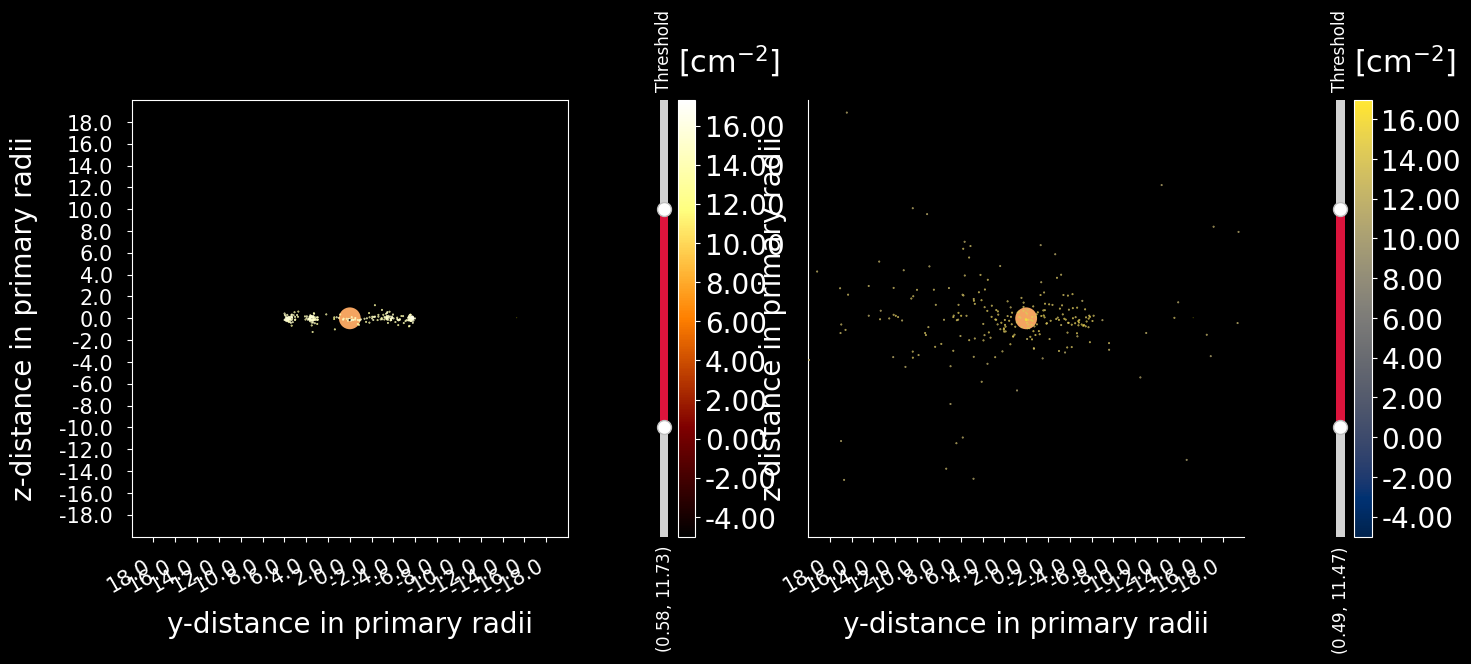

In [12]:
%matplotlib inline

# Basic line of sight plot
sa.plot_lineofsight(timestep=10, figsize=8, single_plot=False, colormap=[mpl.colormaps["afmhot"], mpl.colormaps["cividis"]])

In [ ]:
%matplotlib inline

# Line of sight plot with customizations
sa.plot_lineofsight(
    timestep=4,
    scatter=True,       # Show density scatter
    figsize=8,
    colormap=matplotlib.colormaps["afmhot"],
    #single_plot=True,    # Combine all species in one plot (if multiple are present)
)

### 3. 1D Cut Visualization

The `plot_1d_cut` function creates a 1D density profile along a line extending from the source object.

In [ ]:
# Basic 1D cut plot
sa.plot_1d_cut(timestep=10, figsize=(4,4), max_distance_rp=10)

In [ ]:
# 1D cut plot with customizations
sa.plot_1d_cut(
    timestep=10,
    species_num=1,      # Index of the species to visualize
    log_scale=True,     # Use logarithmic scale for density
    max_distance_rp=4,  # Maximum distance in planet radii
    figsize=(4,4)
)

### 4. 3D Visualization

The `plot_3d` function creates an interactive 3D plot of the particle distribution.

In [ ]:
# Basic 3D plot
fig = sa.plot_3d(timestep=10)
fig.update_layout(template="plotly_dark")
fig.show()

In [17]:
# 3D plot with customizations
fig = sa.plot_3d(
    timestep=10,
    species_num=1,      # Index of the species to visualize
    log_cutoff=1,       # Minimum log density to display
    show_star=False      # Show the star in the visualization (Not recommended for Solar System for obvious reasons)
)
fig.update_layout(template="plotly_dark")
fig.show()

### 5. Phase Curve Calculation and Visualization

The `calculate_phasecurve` function calculates the phase curve data, and `plot_phasecurve` visualizes it.

In [7]:
# Calculate the phase curve for Io with Sodium
sa.calculate_phasecurve('moon', orbits=2)     # More than 1 orbit needs to be run. Otherwise errors may occur.

Calculating phase curve: 100%|██████████| 19/19 [01:14<00:00,  3.90s/it]


<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the phase curve
SerpensAnalyzer.plot_phasecurve(
    filename='phase-curve.csv',
    column_density=True,    # Show column density
    particle_density=True,  # Show particle density
    type="max"              # Use maximum density values
)

### Conclusion

This notebook demonstrated the various visualization functions available in the SerpensAnalyzer class. These functions provide different perspectives on the simulation data:

1. `plot_planar`: Top-down view of the orbital plane
2. `plot_lineofsight`: View from the line-of-sight perspective
3. `plot_1d_cut`: 1D density profile along a line
4. `plot_3d`: Interactive 3D visualization
5. `plot_phasecurve`: Visualization of density variations with orbital phase

These visualizations help in understanding the spatial distribution and dynamics of particles in the simulation.